# Parte 3 - Análisis Exploratorio de Datos (EDA)

## Objetivo del análisis
El objetivo de esta etapa es explorar el catálogo de StreamView Analytics para
identificar patrones, tendencias y oportunidades relevantes para la Gerencia
de Contenidos y Adquisición.

El análisis se enfocará en comprender:

- La composición actual del catálogo.
- El desempeño de los contenidos según género, país y otras características.
- La relación entre popularidad, valoración e interacción.
- La evolución temporal del catálogo.
- El comportamiento financiero de las películas.

## 1. Composición del catálogo

Antes de analizar el desempeño de los contenidos, es necesario comprender
cómo está compuesto el catálogo de StreamView Analytics.

En esta sección se analizará la distribución de los contenidos según:

- Tipo de contenido.
- Género.
- País de origen.
- Clasificación por edad.

Este análisis permitirá identificar qué categorías concentran una mayor
presencia dentro del catálogo y establecer una base para los análisis
posteriores.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("streamview_catalogo_limpio.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue,date_added_year,roi
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,Sin información,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000.0,752600867.0,2010,4.561217
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,Sin información,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000.0,839030630.0,2010,5.243941
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,Sin información,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000.0,954305868.0,2010,3.817223
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,Sin información,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000.0,592461732.0,2010,2.278699
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,Sin información,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000.0,494879471.0,2010,2.999270


In [2]:
print("Cantidad de registros:", df.shape[0])
print("Cantidad de variables:", df.shape[1])

df.info()

Cantidad de registros: 31594
Cantidad de variables: 20
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31594 entries, 0 to 31593
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   show_id          31594 non-null  int64  
 1   type             31594 non-null  object 
 2   title            31594 non-null  object 
 3   director         31594 non-null  object 
 4   cast             31594 non-null  object 
 5   country          31594 non-null  object 
 6   date_added       31594 non-null  object 
 7   release_year     31594 non-null  int64  
 8   rating           31594 non-null  float64
 9   duration         31594 non-null  object 
 10  genres           31594 non-null  object 
 11  language         31594 non-null  object 
 12  description      28324 non-null  object 
 13  popularity       31594 non-null  float64
 14  vote_count       31594 non-null  int64  
 15  vote_average     31594 non-null  float64
 16  bud

### 1.1 Distribución por tipo de contenido

La primera exploración busca conocer cómo se distribuye el catálogo entre
películas y series.

Esta información permite comprender la estructura general de la oferta de
StreamView Analytics antes de analizar otras características del contenido.

In [3]:
tipo_contenido = df["type"].value_counts()

tipo_contenido

,count
type,
Movie,16000
TV Show,15594


In [4]:
tipo_porcentaje = df["type"].value_counts(normalize=True) * 100

tipo_porcentaje

,proportion
type,
Movie,50.642527
TV Show,49.357473


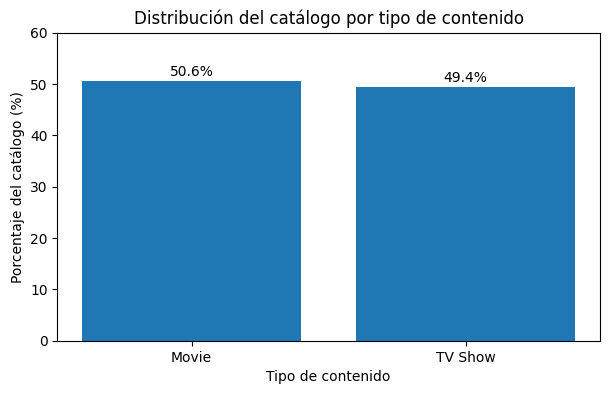

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))

barras = ax.bar(
    tipo_porcentaje.index,
    tipo_porcentaje.values
)

ax.set_title("Distribución del catálogo por tipo de contenido")
ax.set_ylabel("Porcentaje del catálogo (%)")
ax.set_xlabel("Tipo de contenido")
ax.set_ylim(0, 60)

# Mostrar el porcentaje sobre cada barra
for barra in barras:
    valor = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 1,
        f"{valor:.1f}%",
        ha="center"
    )

plt.show()

**Justificación de la visualización:**

Se utilizó un gráfico de barras porque permite comparar directamente la
cantidad relativa de las dos categorías de contenido.

Aunque existen solamente dos categorías, la diferencia entre ambas es
pequeña, por lo que la longitud de las barras facilita una comparación más
precisa que una representación basada en ángulos o áreas.

El eje vertical comienza en cero para evitar exagerar visualmente las
diferencias entre películas y series.

**Hallazgo:**

El catálogo presenta una distribución prácticamente equilibrada entre películas
y series. Las películas representan el 50,64 % del catálogo, mientras que las
series corresponden al 49,36 %.

La diferencia entre ambos tipos de contenido es reducida, por lo que no se
observa una predominancia significativa de uno sobre el otro en términos de
cantidad de títulos.


**Interpretación:**

Este resultado describe únicamente la composición del catálogo. No permite
concluir que películas y series tengan el mismo nivel de popularidad,
valoración o desempeño.

Estas diferencias deberán analizarse posteriormente utilizando variables
como `popularity`, `vote_average` y `vote_count`.



---



### 1.2 Distribución por género

En esta sección se analiza la composición del catálogo según género.

Debido a que un mismo contenido puede estar asociado a más de un género,
es necesario separar los valores contenidos en la variable `genres` antes
de realizar el conteo.

El objetivo es identificar qué géneros concentran una mayor cantidad de
títulos dentro del catálogo.

In [7]:
df["genres"].head(10)

,genres
0,"Comedy, Adventure, Fantasy, Animation, Family"
1,"Action, Science Fiction, Adventure"
2,"Adventure, Fantasy"
3,"Animation, Family, Adventure"
4,"Fantasy, Adventure, Animation, Family"
5,"Drama, Thriller, Mystery"
6,"Action, Adventure, Drama, Family"
7,"Adventure, Action, Science Fiction"
8,Comedy
9,"Drama, Romance"


In [8]:
df["genres"].dropna().sample(10)

,genres
10661,"Drama, Science Fiction"
365,"Music, Drama, History"
3954,"Comedy, Romance"
12816,Drama
23318,Drama
0,"Comedy, Adventure, Fantasy, Animation, Family"
4656,Romance
7928,"Comedy, Crime"
29324,"Drama, Crime"
24134,Drama


In [9]:
df_generos = df.assign(
    genre=df["genres"].str.split(",")
).explode("genre")

df_generos["genre"] = df_generos["genre"].str.strip()

df_generos[["title", "genres", "genre"]].head(15)

,title,genres,genre
0,Shrek Forever After,"Comedy, Adventure, Fantasy, Animation, Family",Comedy
0,Shrek Forever After,"Comedy, Adventure, Fantasy, Animation, Family",Adventure
0,Shrek Forever After,"Comedy, Adventure, Fantasy, Animation, Family",Fantasy
0,Shrek Forever After,"Comedy, Adventure, Fantasy, Animation, Family",Animation
0,Shrek Forever After,"Comedy, Adventure, Fantasy, Animation, Family",Family
1,Inception,"Action, Science Fiction, Adventure",Action
1,Inception,"Action, Science Fiction, Adventure",Science Fiction
1,Inception,"Action, Science Fiction, Adventure",Adventure
2,Harry Potter and the Deathly Hallows: Part 1,"Adventure, Fantasy",Adventure
2,Harry Potter and the Deathly Hallows: Part 1,"Adventure, Fantasy",Fantasy


In [10]:
generos_conteo = df_generos["genre"].value_counts()

generos_conteo

,count
genre,
Drama,14575
Comedy,8984
Animation,4001
Thriller,3769
Action,3239
Crime,3168
Family,2967
Romance,2571
Mystery,2556


In [11]:
print("Cantidad de géneros diferentes:", df_generos["genre"].nunique())
print("Total de asociaciones contenido-género:", df_generos["genre"].count())

Cantidad de géneros diferentes: 29
Total de asociaciones contenido-género: 66245


#### Estandarización de las categorías de género

Durante la exploración de la variable `genres` se identificaron diferencias
en la forma en que algunos géneros se encuentran representados.

Por ejemplo, existen categorías compuestas como `Action & Adventure` y
`Sci-Fi & Fantasy`, mientras que en otros registros estos conceptos aparecen
como géneros separados (`Action`, `Adventure`, `Science Fiction` y `Fantasy`).

También se identificaron dos formas de representar la ausencia de información:
`Unknown` y `Sin información`.

Para evitar que estas diferencias de nomenclatura distorsionen el análisis,
se estandarizarán estas categorías antes de calcular la distribución final
de géneros.

In [12]:
# Reemplazar categorías compuestas por géneros separados
df_generos["genre"] = df_generos["genre"].replace({
    "Action & Adventure": "Action|Adventure",
    "Sci-Fi & Fantasy": "Science Fiction|Fantasy",
    "Unknown": "Sin información"
})

# Separar nuevamente las categorías que acabamos de combinar con |
df_generos["genre"] = df_generos["genre"].str.split("|")

# Crear una fila por cada género
df_generos = df_generos.explode("genre")

# Eliminar posibles espacios
df_generos["genre"] = df_generos["genre"].str.strip()

In [13]:
generos_conteo = df_generos["genre"].value_counts()

generos_conteo

,count
genre,
Drama,14575
Comedy,8984
Action,5174
Animation,4001
Thriller,3769
Adventure,3703
Science Fiction,3363
Fantasy,3359
Crime,3168


In [14]:
print("Cantidad de géneros después de estandarizar:",
      df_generos["genre"].nunique())

Cantidad de géneros después de estandarizar: 26


#### Selección de categorías para la visualización

Luego de estandarizar las categorías se identificaron 26 géneros diferentes.

Para facilitar la lectura y reducir la carga cognitiva, la visualización se
centrará en los 10 géneros con mayor cantidad de asociaciones dentro del
catálogo.

Las categorías restantes se conservan en el análisis, pero no se incluyen en
esta visualización debido a su menor frecuencia.

In [15]:
top_10_generos = generos_conteo.head(10)

top_10_generos

,count
genre,
Drama,14575
Comedy,8984
Action,5174
Animation,4001
Thriller,3769
Adventure,3703
Science Fiction,3363
Fantasy,3359
Crime,3168


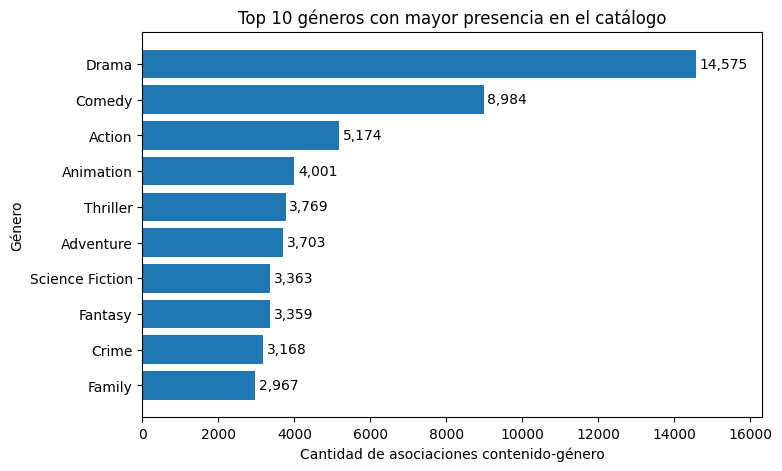

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.barh(
    top_10_generos.index[::-1],
    top_10_generos.values[::-1]
)

ax.set_title("Top 10 géneros con mayor presencia en el catálogo")
ax.set_xlabel("Cantidad de asociaciones contenido-género")
ax.set_ylabel("Género")

ax.set_xlim(0, top_10_generos.max() * 1.12)

for barra in barras:
    valor = barra.get_width()
    ax.text(
        valor + 100,
        barra.get_y() + barra.get_height() / 2,
        f"{int(valor):,}",
        va="center"
    )

plt.show()

**Justificación de la visualización:**

Se utilizó un gráfico de barras horizontales porque permite comparar de forma
clara la frecuencia de múltiples categorías y facilita la lectura de los
nombres de los géneros.

La visualización se limita a los 10 géneros con mayor presencia para evitar
sobrecargar el gráfico con categorías de baja frecuencia y favorecer una
interpretación rápida de las diferencias entre ellas.

**Hallazgo:**

Drama es el género con mayor presencia dentro del catálogo, con 14.575
asociaciones, seguido por Comedy con 8.984.

A partir del tercer lugar se observa una disminución importante en la cantidad
de asociaciones. Action registra 5.174, mientras que Animation, Thriller,
Adventure, Science Fiction y Fantasy presentan valores cercanos entre sí.

Esto indica que la composición del catálogo se encuentra fuertemente
concentrada en contenidos asociados a Drama y, en menor medida, Comedy.

**Interpretación:**

La mayor presencia de Drama y Comedy describe la composición actual del
catálogo, pero no implica que estos géneros tengan necesariamente un mejor
desempeño.

Para evaluar su rendimiento será necesario cruzar posteriormente los géneros
con variables como `popularity`, `vote_average` y `vote_count`.

### 1.3 Distribución por país de origen

En esta sección se analiza la composición del catálogo según el país de origen
de los contenidos.

Debido a que algunos títulos pueden estar asociados a más de un país, primero
se revisará la estructura de la variable `country` antes de realizar el conteo.

El objetivo es identificar qué países concentran una mayor presencia dentro
del catálogo de StreamView Analytics.

In [18]:
df["country"].head(10)

,country
0,United States of America
1,"United Kingdom, United States of America"
2,"United Kingdom, United States of America"
3,United States of America
4,United States of America
5,United States of America
6,"China, Hong Kong, United States of America"
7,United States of America
8,United States of America
9,"France, Spain"


In [19]:
df["country"].dropna().sample(10)

,country
16874,Sin información
23438,South Korea
14631,"Denmark, Sweden"
11447,United States of America
22977,"Colombia, United States of America"
852,United States of America
24805,Chile
2092,United States of America
15030,Indonesia
31498,South Korea


In [20]:
df_paises = df.assign(
    country_individual=df["country"].str.split(",")
).explode("country_individual")

df_paises["country_individual"] = (
    df_paises["country_individual"].str.strip()
)

df_paises[["title", "country", "country_individual"]].head(15)

,title,country,country_individual
0,Shrek Forever After,United States of America,United States of America
1,Inception,"United Kingdom, United States of America",United Kingdom
1,Inception,"United Kingdom, United States of America",United States of America
2,Harry Potter and the Deathly Hallows: Part 1,"United Kingdom, United States of America",United Kingdom
2,Harry Potter and the Deathly Hallows: Part 1,"United Kingdom, United States of America",United States of America
3,Tangled,United States of America,United States of America
4,How to Train Your Dragon,United States of America,United States of America
5,Shutter Island,United States of America,United States of America
6,The Karate Kid,"China, Hong Kong, United States of America",China
6,The Karate Kid,"China, Hong Kong, United States of America",Hong Kong


In [21]:
paises_conteo = df_paises["country_individual"].value_counts()

paises_conteo

,count
country_individual,
United States of America,10874
Japan,2822
United Kingdom,2583
China,2369
Sin información,2217
...,...
Palau,1
Brunei Darussalam,1
Fiji,1


In [22]:
print(
    "Cantidad de países/categorías diferentes:",
    df_paises["country_individual"].nunique()
)

print(
    "Total de asociaciones contenido-país:",
    df_paises["country_individual"].count()
)

Cantidad de países/categorías diferentes: 148
Total de asociaciones contenido-país: 39444


In [23]:
df_paises[
    df_paises["country_individual"]
    .str.contains("Unknown|Sin información", case=False, na=False)
]["country_individual"].value_counts()

,count
country_individual,
Sin información,2217


#### Tratamiento de registros sin país identificado

Se identificaron 2.217 asociaciones correspondientes a la categoría
`Sin información`.

Debido a que esta categoría representa ausencia de información y no un país
de origen, se mantendrá en los datos pero será excluida de la visualización
utilizada para comparar la presencia de los distintos países.

In [24]:
paises_validos = paises_conteo.drop(
    labels="Sin información",
    errors="ignore"
)

top_10_paises = paises_validos.head(10)

top_10_paises

,count
country_individual,
United States of America,10874
Japan,2822
United Kingdom,2583
China,2369
South Korea,2139
France,2099
Canada,1697
Germany,1155
India,902


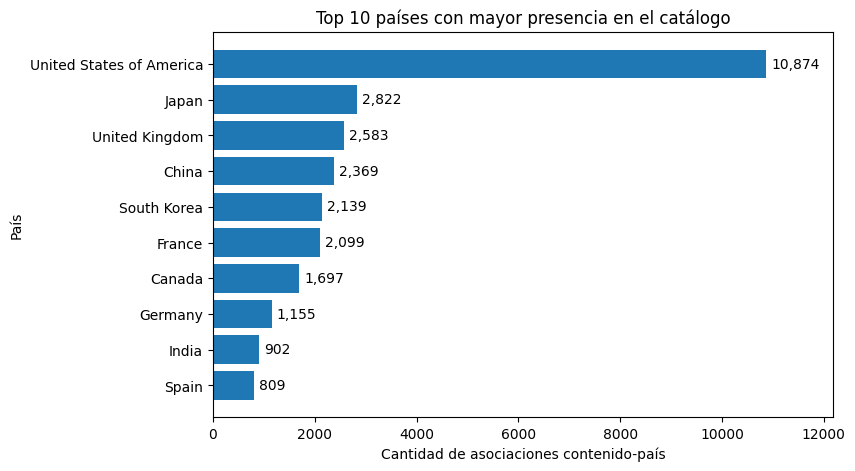

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.barh(
    top_10_paises.index[::-1],
    top_10_paises.values[::-1]
)

ax.set_title("Top 10 países con mayor presencia en el catálogo")
ax.set_xlabel("Cantidad de asociaciones contenido-país")
ax.set_ylabel("País")

# Espacio adicional para mostrar los valores
ax.set_xlim(0, top_10_paises.max() * 1.12)

for barra in barras:
    valor = barra.get_width()

    ax.text(
        valor + 100,
        barra.get_y() + barra.get_height() / 2,
        f"{int(valor):,}",
        va="center"
    )

plt.show()

**Justificación de la visualización:**

Se utilizó un gráfico de barras horizontales para comparar la presencia de
los países con mayor cantidad de asociaciones dentro del catálogo.

Se seleccionaron los 10 países con mayor frecuencia para facilitar la lectura
y reducir la carga visual, considerando que se identificaron 148 categorías
de país diferentes.

Se mantuvo una escala lineal para representar fielmente la diferencia existente
entre Estados Unidos y los demás países. La categoría `Sin información` fue
excluida de la visualización debido a que no representa un país de origen.

**Hallazgo:**

Estados Unidos presenta la mayor participación en el catálogo, con 10.874
asociaciones contenido-país, mostrando una diferencia considerable respecto
del resto de los países.

Japón ocupa el segundo lugar con 2.822 asociaciones, seguido por Reino Unido
con 2.583 y China con 2.369. Corea del Sur y Francia también presentan una
participación relevante, con valores superiores a 2.000 asociaciones.

A partir de Canadá, con 1.697 asociaciones, se observa una nueva disminución
en la presencia de los países dentro del catálogo.

**Interpretación:**

La composición del catálogo muestra una fuerte presencia de contenidos
asociados a Estados Unidos, mientras que los demás países presentan una
participación considerablemente menor.

Sin embargo, una mayor presencia no implica necesariamente un mejor desempeño.
Posteriormente será necesario comparar los países con indicadores como
`popularity`, `vote_average` y `vote_count` para identificar mercados cuyos
contenidos puedan presentar un alto rendimiento aun teniendo una menor
representación en el catálogo.

### 1.4 Revisión de la variable `rating`

Durante la exploración se observó que `rating` contiene valores numéricos
entre 0 y 10, por lo que se revisó su relación con `vote_average` antes de
incorporarla al análisis.

In [27]:
df[["type", "rating", "vote_average"]].head(20)

,type,rating,vote_average
0,Movie,6.380,6.380
1,Movie,8.369,8.369
2,Movie,7.744,7.744
3,Movie,7.600,7.600
4,Movie,7.800,7.800
5,Movie,8.200,8.200
6,Movie,6.500,6.500
7,Movie,6.800,6.800
8,Movie,6.394,6.394
9,Movie,6.416,6.416


In [28]:
df.groupby("type")[["rating", "vote_average"]].describe()

rating                                                 vote_average  \
           count      mean       std  min  25%  50%    75%   max        count   
type                                                                            
Movie    16000.0  5.956368  1.754741  0.0  5.6  6.3  6.923  10.0      16000.0   
TV Show  15594.0  5.412947  3.270188  0.0  2.5  6.8  7.800  10.0      15594.0   

                                                         
             mean       std  min  25%  50%    75%   max  
type                                                     
Movie    5.956368  1.754741  0.0  5.6  6.3  6.923  10.0  
TV Show  5.412947  3.270188  0.0  2.5  6.8  7.800  10.0

In [32]:
# Comprobar si ambas columnas son idénticas en todos los registros
print("¿Son idénticas?:", (df["rating"] == df["vote_average"]).all())
print("Cantidad de valores diferentes:",
      (df["rating"] != df["vote_average"]).sum())

¿Son idénticas?: True
Cantidad de valores diferentes: 0


**Hallazgo:**

La comparación confirmó que `rating` y `vote_average` contienen exactamente
los mismos valores en todos los registros del dataset.

Por lo tanto, `rating` se considera una variable redundante. Para evitar
duplicar información en los análisis posteriores, se utilizará
`vote_average` como variable principal de valoración de los contenidos.

## 2. Desempeño por género

Luego de analizar la composición del catálogo, se evaluará si los géneros con
mayor presencia son también los que presentan mejor desempeño.

Para ello se utilizarán tres indicadores:

- `popularity`: indicador relativo de popularidad.
- `vote_average`: valoración promedio del contenido.
- `vote_count`: cantidad de votos registrados.

Antes de comparar los géneros, se revisará la calidad y distribución de estas
variables para definir qué medidas son más apropiadas para el análisis.

### 2.1 Revisión de la variable de valoración

Antes de calcular valoraciones promedio por género, se revisaron los registros
con `vote_average = 0` para determinar si representan una valoración real o
ausencia de información suficiente.

In [33]:
df["vote_average"].describe()

,vote_average
count,31594.000000
mean,5.688149
std,2.628933
min,0.000000
25%,5.300000
50%,6.481000
75%,7.300000
max,10.000000


In [34]:
print(
    "Cantidad de contenidos con vote_average = 0:",
    (df["vote_average"] == 0).sum()
)

print(
    "Porcentaje:",
    round((df["vote_average"] == 0).mean() * 100, 2),
    "%"
)

Cantidad de contenidos con vote_average = 0: 4491
Porcentaje: 14.21 %


In [35]:
df.loc[
    df["vote_average"] == 0,
    ["title", "type", "vote_average", "vote_count", "popularity"]
].head(20)

,title,type,vote_average,vote_count,popularity
853,Eros Photographer,Movie,0.0,0,4.588
1989,Sonríe,Movie,0.0,0,4.399
2480,YtF,Movie,0.0,0,9.069
2983,SP Woman - Beautiful Sacrifice,Movie,0.0,0,4.903
3256,Torchlighters: The Augustine Story,Movie,0.0,0,14.589
3767,Invisible Hentai Man,Movie,0.0,0,6.475
4581,48 Days,Movie,0.0,0,9.261
4609,An Affair: A Dangerous Sexual Play,Movie,0.0,0,8.870
5120,Isuca: Gokuraku,Movie,0.0,0,24.842
5512,Hipster,Movie,0.0,0,9.412


In [36]:
df.loc[
    df["vote_average"] == 0,
    "vote_count"
].value_counts().head(10)

,count
vote_count,
0,4474
1,17


**Conclusión metodológica:**

Se identificaron 4.491 contenidos con `vote_average = 0`, equivalentes al
14,21 % del catálogo.

De ellos, 4.474 no registran votos y 17 presentan solamente un voto. Por esta
razón, los valores iguales a cero se interpretarán como contenidos sin una
valoración suficientemente representativa.

Estos registros no serán considerados al calcular la valoración promedio por
género, pero permanecerán disponibles para los análisis de otras variables,
como popularidad.

### 2.2 Revisión de la distribución de popularidad

Antes de comparar la popularidad entre géneros, se revisó la distribución de
`popularity` para determinar si era más apropiado utilizar la media o la
mediana como medida de tendencia central.

In [37]:
df["popularity"].describe()

,popularity
count,31594.000000
mean,42.326266
std,111.719350
min,2.323000
25%,10.401250
50%,21.867500
75%,41.158250
max,6421.923000


In [38]:
print("Media de popularidad:", df["popularity"].mean())
print("Mediana de popularidad:", df["popularity"].median())

Media de popularidad: 42.32626625308603
Mediana de popularidad: 21.8675


In [39]:
df[
    ["title", "type", "popularity", "vote_average", "vote_count"]
].sort_values(
    "popularity",
    ascending=False
).head(10)

,title,type,popularity,vote_average,vote_count
20854,The Late Show with Stephen Colbert,TV Show,6421.923,6.493,288
19882,The Tonight Show Starring Jimmy Fallon,TV Show,4925.253,5.800,321
15000,The Gorge,Movie,3876.006,7.785,1572
17949,Good Mythical Morning,TV Show,3414.466,6.800,67
15001,Flight Risk,Movie,3320.616,6.000,350
23772,Chronicles of the Sun,TV Show,2987.485,6.800,117
29640,Volta por Cima,TV Show,2885.720,5.781,16
29641,She's the One,TV Show,2862.872,8.100,9
14000,Mufasa: The Lion King,Movie,2643.627,7.467,1497
29644,Crazy About You,TV Show,2442.243,5.200,16


**Conclusión metodológica:**

La popularidad presenta una distribución fuertemente asimétrica. La media es
aproximadamente 42,33, mientras que la mediana es 21,89, y existen valores
extremos que superan ampliamente al resto de los contenidos.

Por esta razón, se utilizará la **mediana de popularidad** como indicador
principal para comparar géneros, ya que representa mejor el comportamiento
típico y es menos sensible a valores extremos.

La media se mantendrá únicamente como información complementaria.

### 2.3 Construcción de indicadores de desempeño por género

A partir de las decisiones anteriores, se calcularán para cada género los
siguientes indicadores:

- Cantidad de contenidos.
- Mediana de popularidad.
- Promedio de popularidad como referencia complementaria.
- Total de votos.
- Valoración promedio, considerando solamente contenidos con
  `vote_average > 0`.
- Cantidad de contenidos efectivamente valorados.

In [40]:
desempeno_genero = (
    df_generos
    .groupby("genre")
    .agg(
        cantidad_contenidos=("show_id", "nunique"),
        popularidad_mediana=("popularity", "median"),
        popularidad_promedio=("popularity", "mean"),
        votos_totales=("vote_count", "sum")
    )
)

In [41]:
valoracion_genero = (
    df_generos[df_generos["vote_average"] > 0]
    .groupby("genre")
    .agg(
        valoracion_promedio=("vote_average", "mean"),
        contenidos_valorados=("show_id", "nunique")
    )
)

In [42]:
desempeno_genero = desempeno_genero.join(valoracion_genero)

desempeno_genero

,cantidad_contenidos,popularidad_mediana,popularidad_promedio,votos_totales,valoracion_promedio,contenidos_valorados
genre,,,,,,
Action,5174,23.0125,45.452102,4726252,6.645898,4928
Adventure,3703,28.2780,52.264749,4032304,6.937090,3490
Animation,4000,26.8320,45.473947,1483967,7.181603,3737
Comedy,8983,21.7405,42.612394,3671029,6.657576,8191
Crime,3168,21.3220,40.573622,1819162,6.726720,2970
Documentary,1803,14.9140,28.345769,150512,7.237430,1410
Drama,14571,22.4320,41.548575,5553628,6.754330,12800
Family,2967,25.8190,54.444199,1396847,6.826335,2601
Fantasy,3359,27.4120,45.817357,2365342,6.988168,3147


**Observación inicial:**

La tabla muestra que los géneros con mayor cantidad de contenidos no son
necesariamente los que presentan mayor popularidad o valoración.

Por esta razón, los siguientes análisis compararán estas métricas por separado,
evitando interpretar la cantidad de títulos como sinónimo de desempeño.

### 2.4 Popularidad por género

Para identificar qué géneros presentan una mayor popularidad típica, se
comparará la mediana de `popularity` calculada previamente.

Se considerarán únicamente géneros con al menos 500 contenidos, con el objetivo
de evitar que categorías con muy pocos registros tengan una influencia
desproporcionada en la comparación.

Además, se excluirá la categoría `Sin información`, debido a que no representa
un género de contenido.

Finalmente, se visualizarán los 10 géneros con mayor mediana de popularidad
para facilitar su comparación.

In [48]:
generos_populares = (
    desempeno_genero[
        (desempeno_genero["cantidad_contenidos"] >= 500) &
        (desempeno_genero.index != "Sin información")
    ]
    .sort_values("popularidad_mediana", ascending=False)
)

top_popularidad = generos_populares.head(10)

top_popularidad[
    ["cantidad_contenidos", "popularidad_mediana"]
]

,cantidad_contenidos,popularidad_mediana
genre,,
Soap,615,88.1160
Talk,643,51.0720
Reality,1589,41.0335
Kids,812,40.9880
Adventure,3703,28.2780
Science Fiction,3363,27.6090
Fantasy,3359,27.4120
Animation,4000,26.8320
Family,2967,25.8190


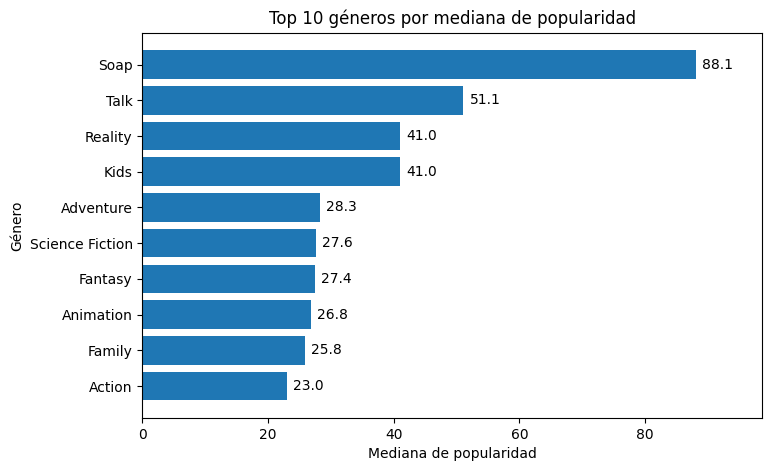

In [49]:
fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.barh(
    top_popularidad.index[::-1],
    top_popularidad["popularidad_mediana"].values[::-1]
)

ax.set_title("Top 10 géneros por mediana de popularidad")
ax.set_xlabel("Mediana de popularidad")
ax.set_ylabel("Género")

ax.set_xlim(
    0,
    top_popularidad["popularidad_mediana"].max() * 1.12
)

for barra in barras:
    valor = barra.get_width()

    ax.text(
        valor + 1,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.1f}",
        va="center"
    )

plt.show()

**Justificación de la visualización:**

Se utilizó un gráfico de barras horizontales porque permite comparar de forma
directa la popularidad típica de diferentes géneros y facilita la lectura de
sus nombres.

Los géneros se presentan ordenados según su mediana de popularidad, permitiendo
identificar rápidamente aquellos que presentan los valores más altos.

**Hallazgo:**

Los resultados muestran diferencias importantes en la popularidad típica de
los géneros analizados. `Soap` presenta la mayor mediana de popularidad, con
88,1, seguido por `Talk` con 51,1. `Reality` y `Kids` presentan valores cercanos
a 41.

En contraste, géneros con una presencia mucho mayor dentro del catálogo, como
`Action`, presentan una mediana de popularidad considerablemente menor.

Estos resultados muestran que una mayor cantidad de contenidos disponibles no
implica necesariamente una mayor popularidad típica del género.

**Interpretación:**

El resultado sugiere que algunos géneros con una presencia relativamente menor
en el catálogo pueden alcanzar niveles de popularidad superiores a categorías
con una oferta más amplia.

Esto convierte a géneros como `Soap`, `Talk`, `Reality` y `Kids` en categorías
de interés para análisis posteriores. Sin embargo, la popularidad por sí sola
no es suficiente para recomendar una mayor adquisición de estos contenidos,
por lo que será necesario contrastarla con otros indicadores de desempeño,
como valoración y cantidad de votos.

### 2.5 Valoración por género

En esta sección se analizará qué géneros presentan una mayor valoración
promedio por parte de los usuarios.

Para evitar que géneros con muy pocos contenidos valorados generen resultados
poco representativos, se considerarán únicamente aquellos con al menos 500
contenidos con `vote_average > 0`.

La valoración promedio se calculará utilizando solamente registros con una
valoración válida, según lo definido en la sección 2.1.

In [50]:
generos_valorados = (
    desempeno_genero[
        desempeno_genero["contenidos_valorados"] >= 500
    ]
    .sort_values("valoracion_promedio", ascending=False)
)

top_valoracion = generos_valorados.head(10)

top_valoracion[
    ["contenidos_valorados", "valoracion_promedio"]
]

,contenidos_valorados,valoracion_promedio
genre,,
Kids,658,7.250912
Documentary,1410,7.237430
Animation,3737,7.181603
Fantasy,3147,6.988168
Adventure,3490,6.937090
Reality,1180,6.870892
Family,2601,6.826335
Science Fiction,3150,6.824931
History,721,6.771319


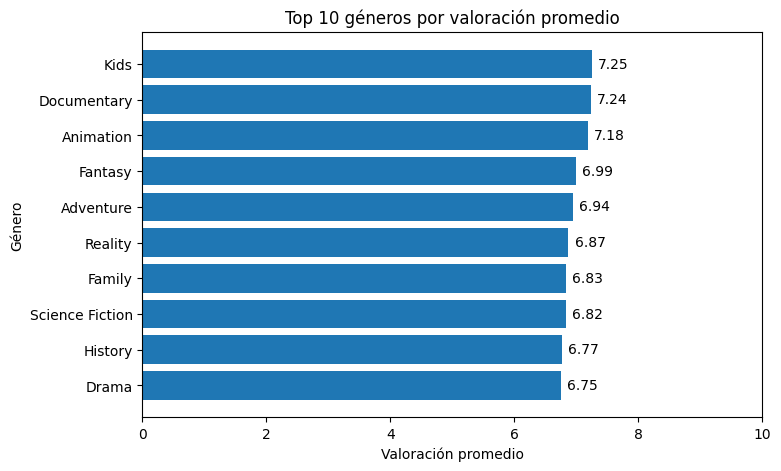

In [51]:
fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.barh(
    top_valoracion.index[::-1],
    top_valoracion["valoracion_promedio"].values[::-1]
)

ax.set_title("Top 10 géneros por valoración promedio")
ax.set_xlabel("Valoración promedio")
ax.set_ylabel("Género")

# La escala natural de vote_average es de 0 a 10
ax.set_xlim(0, 10)

for barra in barras:
    valor = barra.get_width()

    ax.text(
        valor + 0.1,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.2f}",
        va="center"
    )

plt.show()

**Justificación de la visualización:**

Se utilizó un gráfico de barras horizontales para facilitar la comparación
entre las valoraciones promedio de los distintos géneros.

El eje horizontal se mantuvo entre 0 y 10, correspondiente a la escala real
de `vote_average`, con el objetivo de representar las diferencias de manera
proporcional y evitar exagerarlas visualmente.

Se incluyeron únicamente géneros con al menos 500 contenidos valorados para
obtener una comparación basada en una cantidad suficiente de observaciones.

**Interpretación:**

Los resultados muestran que una alta popularidad no necesariamente coincide
con una mayor valoración.

Por ejemplo, `Soap` y `Talk`, que destacaron por su alta mediana de popularidad,
no aparecen entre los géneros con mayor valoración promedio. En cambio,
`Kids` presenta un comportamiento favorable en ambos indicadores, mientras
que `Documentary` y `Animation` destacan principalmente por su valoración.

Esto sugiere que popularidad y valoración representan dimensiones diferentes
del desempeño y deben analizarse de manera complementaria.